# Heat Equation Solver (Finite Differences)

We solve the 1D heat equation:

$$
\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}
$$

with Dirichlet boundary conditions and a smooth initial profile. The scheme uses explicit Euler time stepping with a finite-difference Laplacian. Stability requires $r = \alpha \Delta t / \Delta x^2 \le 1/2$.

## 1. Import Required Libraries

We use NumPy for arrays and Matplotlib for visualization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Set Physical Parameters and Grid

We define the domain, discretization, and stability-friendly time step.

In [2]:
alpha = 0.5
length = 1.0
nx = 200
x = np.linspace(0.0, length, nx)
dx = x[1] - x[0]

# Stability: r = alpha * dt / dx^2 <= 1/2 for explicit Euler
r = 0.4
dt = r * dx * dx / alpha

t_final = 0.25
nt = int(np.ceil(t_final / dt))

dt = t_final / nt
r = alpha * dt / (dx * dx)

print(f"dx={dx:.4f}, dt={dt:.6f}, nt={nt}, r={r:.4f}")

dx=0.0050, dt=0.000020, nt=12376, r=0.4000


## 3. Initialize Temperature Field

We use a sine mode that matches homogeneous Dirichlet boundaries.

In [3]:
u0 = np.sin(np.pi * x / length)

# Dirichlet boundary conditions: u=0 at x=0 and x=L
u0[0] = 0.0
u0[-1] = 0.0

u = u0.copy()

## 4. Define Time-Stepping Scheme (Explicit)

We apply explicit Euler in time with a central-difference Laplacian.

In [4]:
def explicit_step(u, r):
    # Apply Laplacian on interior points only
    u_new = u.copy()
    u_new[1:-1] = u[1:-1] + r * (u[2:] - 2.0 * u[1:-1] + u[:-2])
    u_new[0] = 0.0
    u_new[-1] = 0.0
    return u_new

## 5. Assemble Discrete Laplacian

We build the 1D Laplacian matrix for reference and validation.

In [5]:
n_interior = nx - 2

main = -2.0 * np.ones(n_interior)
off = 1.0 * np.ones(n_interior - 1)

laplacian = (np.diag(main) + np.diag(off, k=1) + np.diag(off, k=-1)) / (dx * dx)

laplacian[:3, :3]

array([[-79202.,  39601.,      0.],
       [ 39601., -79202.,  39601.],
       [     0.,  39601., -79202.]])

## 6. Run the Time Integration Loop

We march the solution forward and store snapshots for plotting.

In [6]:
snapshots = []
snapshot_times = []

u = u0.copy()

for n in range(nt + 1):
    t = n * dt
    if n % max(1, nt // 6) == 0 or n == nt:
        snapshots.append(u.copy())
        snapshot_times.append(t)
    u = explicit_step(u, r)

snapshots = np.array(snapshots)

print(f"Stored {len(snapshots)} snapshots")

Stored 8 snapshots


## 7. Validate Against Analytical Solution

For a single sine mode, the exact solution is $u(x,t)=\sin(\pi x/L)\exp(-\alpha (\pi/L)^2 t)$.

In [7]:
def exact_solution(x, t, alpha, length):
    return np.sin(np.pi * x / length) * np.exp(-alpha * (np.pi / length) ** 2 * t)

u_exact = exact_solution(x, snapshot_times[-1], alpha, length)

error = np.sqrt(np.mean((u - u_exact) ** 2))
print(f"L2 error at t={snapshot_times[-1]:.3f}: {error:.6e}")

L2 error at t=0.250: 2.784210e-05


## 8. Visualize Temperature Evolution

We plot several snapshots and compare the last snapshot to the exact solution.

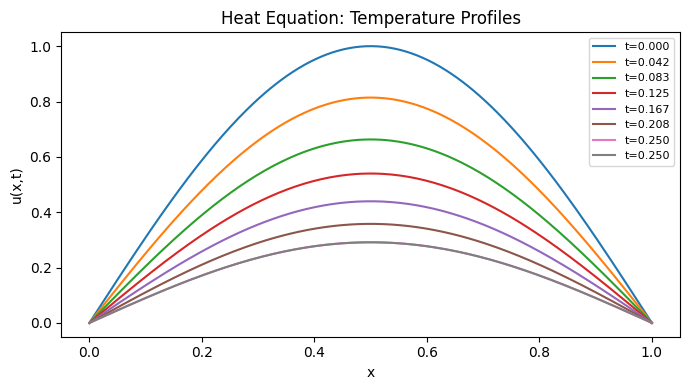

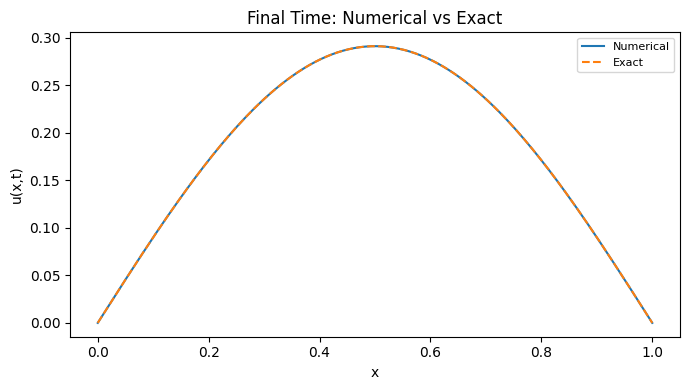

In [8]:
plt.figure(figsize=(7, 4))
for idx, t in enumerate(snapshot_times):
    plt.plot(x, snapshots[idx], label=f"t={t:.3f}")

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Heat Equation: Temperature Profiles")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(x, snapshots[-1], label="Numerical")
plt.plot(x, u_exact, "--", label="Exact")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Final Time: Numerical vs Exact")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

## Neural CDE Pipeline for Heat Equation

Pipeline (mirroring the PI-CDE notebook for transport):
1. Generate multiple random ICs and solve via explicit FD
2. Place "sensors" at selected spatial locations
3. Build lag-windowed sensor sequences → full-field targets
4. Compute POD basis from training snapshots; project targets to POD coefficients
5. Train `NeuralCDE` from `utils.models_diffrax`
6. Physics-informed training with the heat equation residual:
   $$\mathcal{R} = \frac{\partial u}{\partial t} - \alpha\,\frac{\partial^2 u}{\partial x^2}$$

In [9]:
import sys
from pathlib import Path

project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import jax
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import optax
import diffrax

from scipy.interpolate import interp1d
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.extmath import randomized_svd

from utils.models_diffrax import (
    NeuralCDE, prepare_data_CDE, fit_CDE,
    loss_mse_CDE, make_step_CDE,
)

print(f"JAX backend: {jax.default_backend()}")
print(f"Devices: {jax.devices()}")

JAX backend: cpu
Devices: [CpuDevice(id=0)]


In [10]:
# ── 1. Generate training data: multiple random ICs ───────────────────
from scipy.linalg import solve_banded

N_ics = 10          # number of random initial conditions
Nx_cde = 100        # spatial points

x_cde = np.linspace(0.0, length, Nx_cde)
dx_cde = x_cde[1] - x_cde[0]

# Crank-Nicolson is unconditionally stable → use far fewer time steps
Nt_cde = 200        # ~6× fewer than explicit Euler would need
t_cde = np.linspace(0.0, t_final, Nt_cde)
dt_cde = t_cde[1] - t_cde[0]

r_cde = alpha * dt_cde / (dx_cde ** 2)
print(f"Grid: Nx={Nx_cde}, Nt={Nt_cde}, dx={dx_cde:.4f}, dt={dt_cde:.6f}")
print(f"Crank-Nicolson r = {r_cde:.4f}  (unconditionally stable)")


def make_random_fourier_ic(x_grid, n_harmonics=6, rng=None, L=1.0):
    """Random Fourier IC satisfying u(0)=u(L)=0 (Dirichlet) using sine modes."""
    rng = np.random.default_rng() if rng is None else rng
    u = np.zeros_like(x_grid)
    for k in range(1, n_harmonics + 1):
        amp = rng.normal(0, 1.0 / k)
        u += amp * np.sin(k * np.pi * x_grid / L)
    return u


def solve_heat_crank_nicolson(u0_arr, Nt, r):
    """Crank-Nicolson solver for heat equation with Dirichlet BC.

    Scheme (tridiagonal system at each step):
        (I - r/2·L) u^{n+1} = (I + r/2·L) u^n

    Unconditionally stable → allows large time steps.
    """
    Nx = len(u0_arr)
    n_int = Nx - 2  # interior points

    sol = np.zeros((Nt, Nx))
    sol[0] = u0_arr.copy()
    u = u0_arr.copy()

    # Build tridiagonal matrix A = (I - r/2 L) in banded format
    # A[i,i] = 1 + r,  A[i,i±1] = -r/2
    rh = r / 2.0
    diag_main = (1.0 + r) * np.ones(n_int)
    diag_off  = -rh * np.ones(n_int - 1)

    # Banded storage: ab[0] = super-diagonal, ab[1] = main, ab[2] = sub
    ab = np.zeros((3, n_int))
    ab[0, 1:] = diag_off    # super-diagonal
    ab[1, :] = diag_main    # main diagonal
    ab[2, :-1] = diag_off   # sub-diagonal

    for n in range(1, Nt):
        # RHS: b = (I + r/2 L) u^n  on interior
        u_int = u[1:-1]
        b = (1.0 - r) * u_int + rh * (u[:-2] + u[2:])

        # Solve tridiagonal system for interior
        u_int_new = solve_banded((1, 1), ab, b)

        u_new = np.zeros(Nx)
        u_new[1:-1] = u_int_new
        # Dirichlet BC: u[0] = u[-1] = 0 (already zeros)

        sol[n] = u_new
        u = u_new

    return sol


rng_data = np.random.default_rng(42)
U_all = []

for i in range(N_ics):
    seed_i = rng_data.integers(0, 2**31)
    n_harm = rng_data.integers(1, 5)
    ic_i = make_random_fourier_ic(x_cde, n_harmonics=n_harm,
                                   rng=np.random.default_rng(seed_i), L=length)
    U_i = solve_heat_crank_nicolson(ic_i, Nt_cde, r_cde)
    U_all.append(U_i)

U_all = np.array(U_all)   # (N_ics, Nt, Nx)
print(f"Snapshot tensor: {U_all.shape}  (N_ics × Nt × Nx)")

Grid: Nx=100, Nt=200, dx=0.0101, dt=0.001256
Crank-Nicolson r = 6.1564  (unconditionally stable)
Snapshot tensor: (10, 200, 100)  (N_ics × Nt × Nx)


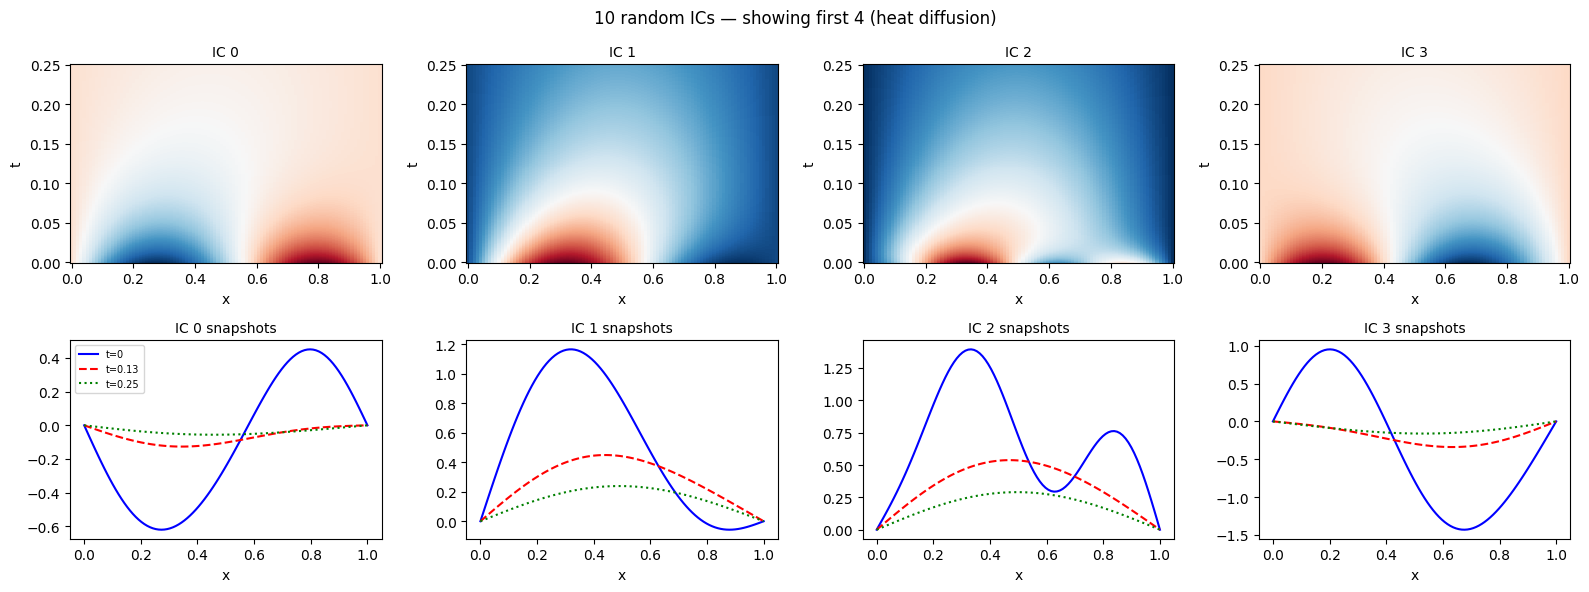

In [11]:
# ── Visualise a few ICs and their heat diffusion ──
fig, axes = plt.subplots(2, 4, figsize=(16, 6))

for i, ax in enumerate(axes[0]):
    ax.pcolormesh(x_cde, t_cde, U_all[i], shading='auto', cmap='RdBu_r')
    ax.set_title(f'IC {i}', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('t')

for i, ax in enumerate(axes[1]):
    ax.plot(x_cde, U_all[i, 0], 'b-', label='t=0')
    ax.plot(x_cde, U_all[i, Nt_cde//2], 'r--', label=f't={t_cde[Nt_cde//2]:.2f}')
    ax.plot(x_cde, U_all[i, -1], 'g:', label=f't={t_cde[-1]:.2f}')
    ax.set_xlabel('x'); ax.set_title(f'IC {i} snapshots', fontsize=10)
    if i == 0: ax.legend(fontsize=7)

plt.suptitle(f'{N_ics} random ICs — showing first 4 (heat diffusion)', fontsize=12)
plt.tight_layout(); plt.show()

In [53]:
# ── 2. Sensor placement & lag-windowed sequences ─────────────────────
nsensors = 5
lag = 25
n_modes = 10       # POD modes to keep

# choose sensor indices evenly spaced
sensor_idx_cde = [int((i+1)/(nsensors+1) * Nx_cde ) for i in range(nsensors)]
print(f"Sensor locations (indices): {sensor_idx_cde}")
print(f"Sensor x-positions: {x_cde[sensor_idx_cde].round(3)}")

X_seq_list = []
Y_full_list = []

for ic_idx in range(N_ics):
    U_i = U_all[ic_idx]                           # (Nt, Nx)
    S_i = U_i[:, sensor_idx_cde]                  # (Nt, nsensors)
    time_col = np.linspace(0, 1, Nt_cde)[:, None] # normalised time
    S_with_time = np.hstack([S_i, time_col])      # (Nt, nsensors+1)
    
    X_i = np.stack([S_with_time[j : j + lag] for j in range(Nt_cde - lag + 1)])
    Y_i = U_i[lag - 1:]
    X_seq_list.append(X_i)
    Y_full_list.append(Y_i)

X_seq = np.concatenate(X_seq_list, axis=0)   # (N_total, lag, nsensors+1)
Y_full = np.concatenate(Y_full_list, axis=0) # (N_total, Nx)

N_samples = X_seq.shape[0]
print(f"\nSequences: X_seq {X_seq.shape}  (N, lag, nsensors+1)")
print(f"Targets:   Y_full {Y_full.shape}  (N, Nx)")
print(f"Total samples: {N_samples}  ({N_ics} ICs × {Nt_cde - lag + 1} windows each)")

Sensor locations (indices): [16, 33, 50, 66, 83]
Sensor x-positions: [0.162 0.333 0.505 0.667 0.838]

Sequences: X_seq (1760, 25, 6)  (N, lag, nsensors+1)
Targets:   Y_full (1760, 100)  (N, Nx)
Total samples: 1760  (10 ICs × 176 windows each)


In [54]:
# ── 3. Train / valid / test split ────────────────────────────────────
train_ratio, valid_ratio = 0.8, 0.1

rng_split = np.random.default_rng(42)
idx_perm = rng_split.permutation(N_samples)
n_train = int(train_ratio * N_samples)
n_valid = int(valid_ratio * N_samples)

train_idx = idx_perm[:n_train]
valid_idx = idx_perm[n_train : n_train + n_valid]
test_idx  = idx_perm[n_train + n_valid:]

X_train, Y_train = X_seq[train_idx], Y_full[train_idx]
X_valid, Y_valid = X_seq[valid_idx], Y_full[valid_idx]
X_test,  Y_test  = X_seq[test_idx],  Y_full[test_idx]

print(f"Train: {X_train.shape[0]}  Valid: {X_valid.shape[0]}  Test: {X_test.shape[0]}")

Train: 1408  Valid: 176  Test: 176


In [55]:
# ── 4. POD basis (from training snapshots only) ─────────────────────
Y_train_2d = Y_train.reshape(-1, Nx_cde)
_, S_vals, Vt = randomized_svd(Y_train_2d, n_components=n_modes, random_state=42)
V = Vt[:n_modes]                # (n_modes, Nx)

Y_rec = (Y_train_2d @ V.T) @ V
rel_err = np.linalg.norm(Y_train_2d - Y_rec) / np.linalg.norm(Y_train_2d)
print(f"POD: {n_modes} modes → relative reconstruction error = {rel_err*100:.4f}%")

pod_train = Y_train @ V.T
pod_valid = Y_valid @ V.T
pod_test  = Y_test  @ V.T

scaler = MinMaxScaler().fit(pod_train)
pod_train_s = scaler.transform(pod_train)
pod_valid_s = scaler.transform(pod_valid)
pod_test_s  = scaler.transform(pod_test)

print(f"POD targets: train {pod_train_s.shape}, valid {pod_valid_s.shape}, test {pod_test_s.shape}")

POD: 10 modes → relative reconstruction error = 0.0000%
POD targets: train (1408, 10), valid (176, 10), test (176, 10)


In [56]:
# ── 5. Prepare CDE data (Hermite coefficients) ──────────────────────
train_cde, data_size = prepare_data_CDE(X_train, pod_train_s)
valid_cde, _         = prepare_data_CDE(X_valid, pod_valid_s)
test_cde,  _         = prepare_data_CDE(X_test,  pod_test_s)

print(f"CDE data_size (sensor channels): {data_size}")
print(f"Train ts: {train_cde['ts'].shape}, Y: {train_cde['Y'].shape}")
print(f"Coeffs: {len(train_cde['coeffs'])} arrays, first shape: {train_cde['coeffs'][0].shape}")

CDE data_size (sensor channels): 5
Train ts: (1408, 25), Y: (1408, 10)
Coeffs: 4 arrays, first shape: (1408, 24, 5)


In [57]:
# ── 6. Instantiate NeuralCDE model ───────────────────────────────────
hidden_size = 100
width_size  = 64
depth       = 2
output_size = n_modes
decoder_sizes = (64, 128)

key = jr.PRNGKey(42)
model_cde = NeuralCDE(
    data_size=data_size,
    hidden_size=hidden_size,
    width_size=width_size,
    depth=depth,
    activation_cde=jax.nn.tanh,
    activation_decoder=jax.nn.gelu,
    output_size=output_size,
    decoder_sizes=decoder_sizes,
    key=key,
)

n_params = sum(p.size for p in jax.tree_util.tree_leaves(eqx.filter(model_cde, eqx.is_inexact_array)))
print(f"NeuralCDE: {n_params:,} parameters")
print(f"  data_size={data_size}, hidden={hidden_size}, width={width_size}, depth={depth}")
print(f"  decoder: {hidden_size}→{'→'.join(map(str, decoder_sizes))}→{output_size}")

NeuralCDE: 71,252 parameters
  data_size=5, hidden=100, width=64, depth=2
  decoder: 100→64→128→10


In [58]:
# ── 7. Train (data-only) ─────────────────────────────────────────────
epochs     = 200
batch_size = 64
lr         = 1e-2

train_losses = []
valid_losses = []
model_cde, train_losses_1, valid_losses_1 = fit_CDE(
    model_cde, train_cde, valid_cde,
    epochs=epochs,
    batch_size=batch_size,
    lr=1e-2,
    seed=42,
    early_stopping=20,
    verbose=True,
) 
train_losses.extend(train_losses_1)
valid_losses.extend(valid_losses_1)

model_cde, train_losses_2, valid_losses_2 = fit_CDE(
    model_cde, train_cde, valid_cde,
    epochs=epochs,
    batch_size=batch_size,
    lr=1e-3,
    seed=42,
    early_stopping=20,
    verbose=True,
)
train_losses.extend(train_losses_2)
valid_losses.extend(valid_losses_2)

Epoch  62/200 | Train 6.6507e-02 | Valid 9.6529e-02 | Time 0.83s | Patience 19/20
Early stopping at epoch 62, best validation loss: 2.7667e-02
Epoch  66/200 | Train 1.8140e-02 | Valid 2.4508e-02 | Time 0.99s | Patience 19/20
Early stopping at epoch 66, best validation loss: 2.4271e-02


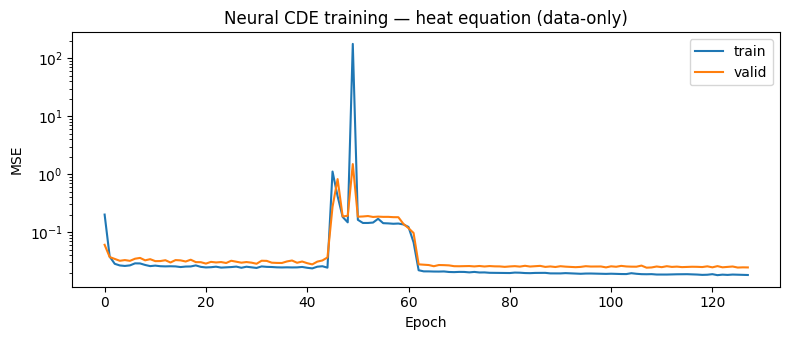

In [59]:
# ── 8. Loss curves ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.semilogy(train_losses, label='train')
ax.semilogy(valid_losses, label='valid')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.set_title('Neural CDE training — heat equation (data-only)')
ax.legend()
plt.tight_layout(); plt.show()

In [60]:
def mse(datapred, datatrue):
    return jnp.mean(jnp.sum((datapred - datatrue)**2, axis = -1))
def rmsre(datapred, datatrue):
    return jnp.mean(jnp.sqrt(jnp.sum((datapred - datatrue)**2, axis = -1))/jnp.sqrt(jnp.sum((datatrue)**2, axis = -1)))

def mae(datapred, datatrue):
    return jnp.mean(jnp.sum(jnp.abs(datapred - datatrue), axis = -1))

def mre(datapred, datatrue):
    return jnp.mean(jnp.abs(datapred - datatrue)) / jnp.mean(jnp.abs(datatrue))


In [61]:
# ── 9. Predict on test set & decode to full field ───────────────────
preds_pod_scaled_test = jax.vmap(model_cde)(test_cde['ts'], test_cde['coeffs'])
preds_pod_test = scaler.inverse_transform(np.array(preds_pod_scaled_test))
preds_data_test = preds_pod_test @ V

mse_test = mse(preds_data_test, Y_test)
rmsre_test = rmsre(preds_data_test, Y_test)
print(f"Test MSE:          {mse_test:.6e}")
print(f'RMSRE:  {rmsre_test*100:.4f}%')

Test MSE:          1.446631e-02
RMSRE:  5.5830%


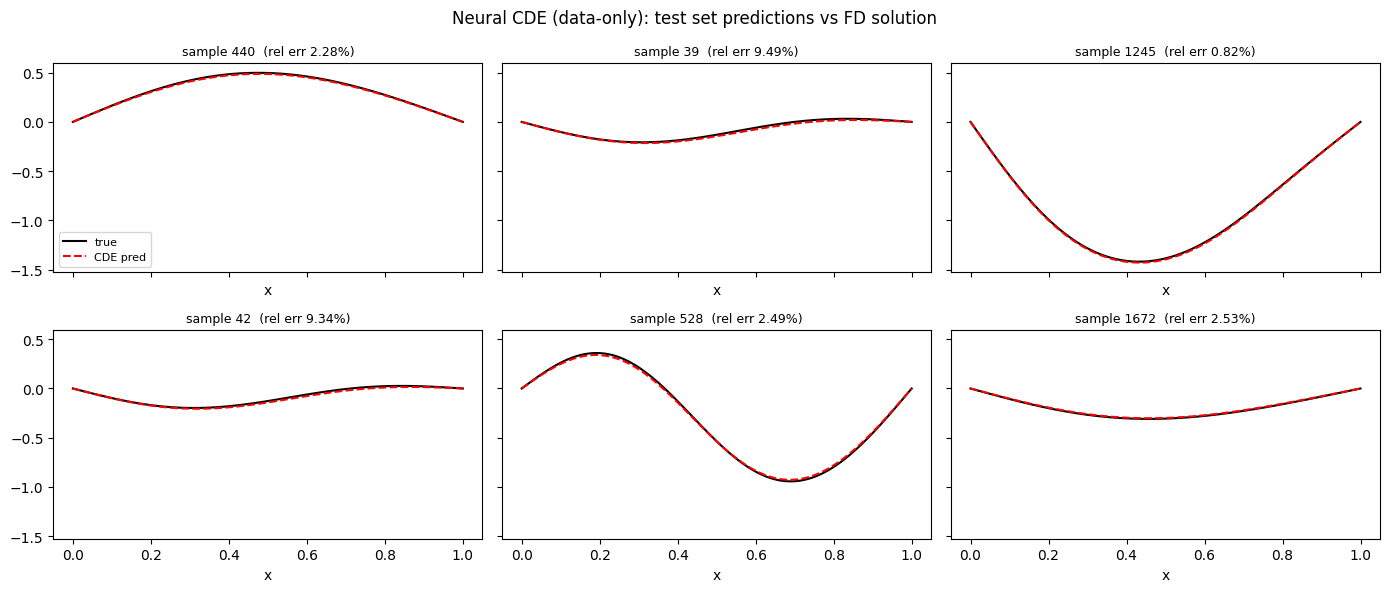

In [62]:
# ── 10. Visualise: predicted vs true for a few test snapshots ────────
fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True, sharey=True)
sample_idx = np.linspace(0, len(test_idx)-1, 6, dtype=int)

for i, ax in enumerate(axes.flat):
    si = sample_idx[i]
    ax.plot(x_cde, Y_test[si], 'k-', lw=1.5, label='true')
    ax.plot(x_cde, preds_data_test[si], 'r--', lw=1.5, label='CDE pred')
    err_i = np.linalg.norm(preds_data_test[si] - Y_test[si]) / (np.linalg.norm(Y_test[si]) + 1e-12)
    ax.set_title(f'sample {test_idx[si]}  (rel err {err_i*100:.2f}%)', fontsize=9)
    ax.set_xlabel('x')
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle('Neural CDE (data-only): test set predictions vs FD solution', fontsize=12)
plt.tight_layout(); plt.show()

## Physics-Informed Neural CDE for Heat Equation

### Heat equation residual

$$\mathcal{R}(x,t) = \frac{\partial u}{\partial t} - \alpha\,\frac{\partial^2 u}{\partial x^2} = 0$$

### Time derivative via CDE dynamics

Using the fundamental theorem of calculus:
$$\frac{dz}{dt} = f_\theta(z(t))\;\frac{dX}{dt}(t)$$

Chain-rule through the decoder:
$$\frac{d\hat{a}}{dt} = \frac{1}{T}\;\frac{D'(z) \cdot dz/dt}{\text{scale}}$$

### Spatial derivative via POD basis

We precompute the **second** spatial derivative of POD modes:
$$\frac{\partial^2 V_k}{\partial x^2}\bigg|_i \approx \frac{V_k[i{+}1] - 2V_k[i] + V_k[i{-}1]}{\Delta x^2}$$

Then:
$$\frac{\partial^2 \hat{u}}{\partial x^2}(x,t) = \hat{a}(t)^T V_{xx}$$

### Combined residual

$$\mathcal{R} = \dot{\hat{a}}^T V - \alpha\;\hat{a}^T V_{xx}$$

V   shape: (10, 100)   (n_modes × Nx)
Vx  shape: (10, 100)  (dV/dx)
Vxx shape: (10, 100) (d²V/dx²)


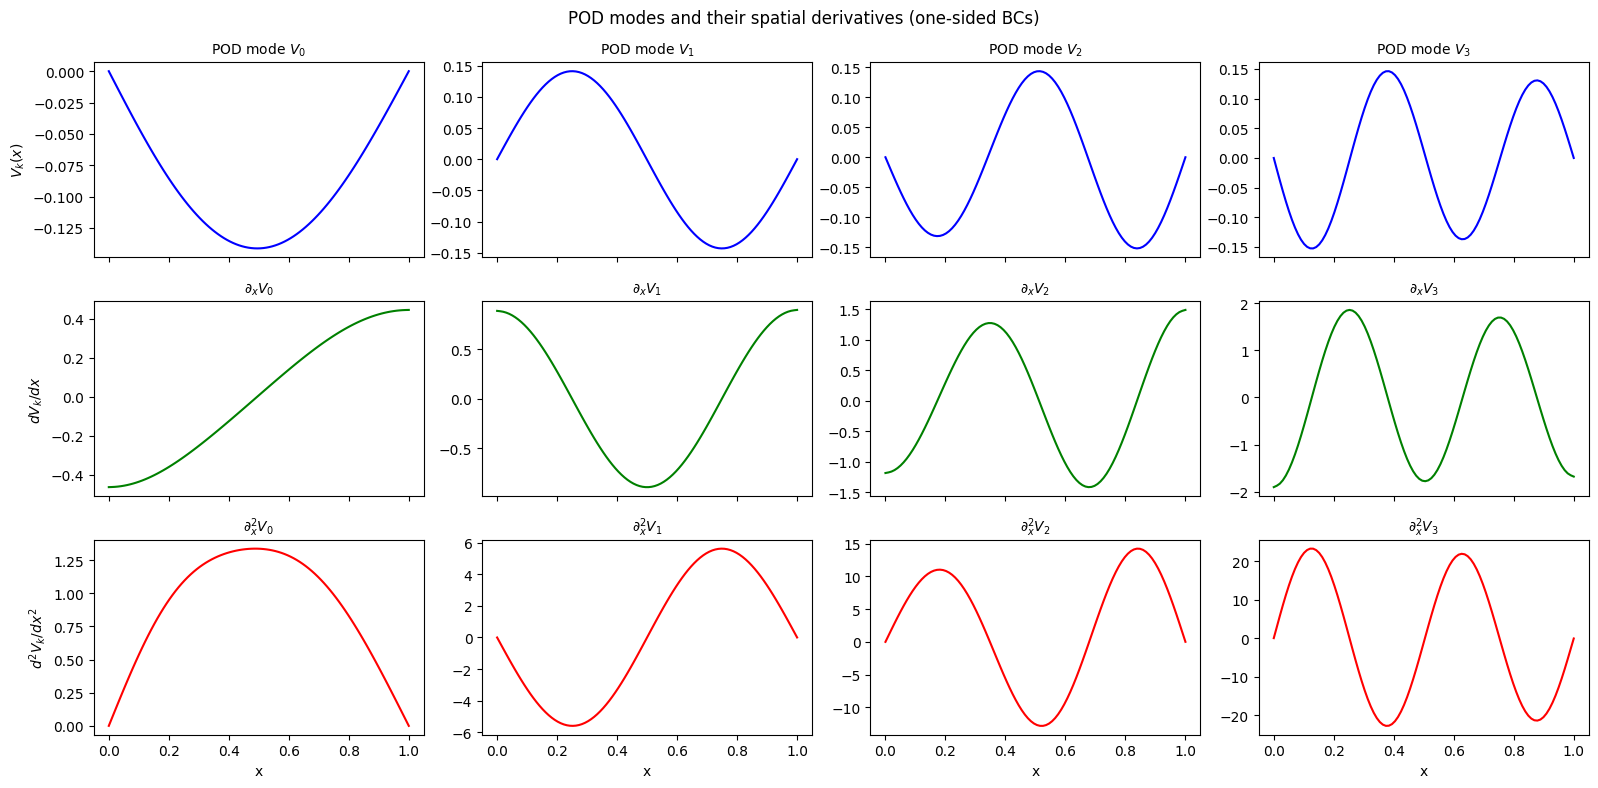

In [63]:

# ── 11. Spatial derivatives of POD basis (one-sided stencils at BCs) ─
# NOTE: V has shape (n_modes, Nx_cde); dx_cde is the grid spacing.

# ── First derivative Vx ──────────────────────────────────────────────
Vx = np.zeros_like(V)
# Interior: 2nd-order central difference
Vx[:, 1:-1] = (V[:, 2:] - V[:, :-2]) / (2 * dx_cde)
# Left boundary: 2nd-order forward difference
Vx[:, 0]    = (-3*V[:, 0] + 4*V[:, 1]  - V[:, 2])  / (2 * dx_cde)
# Right boundary: 2nd-order backward difference
Vx[:, -1]   = ( 3*V[:, -1] - 4*V[:, -2] + V[:, -3]) / (2 * dx_cde)

# ── Second derivative Vxx ────────────────────────────────────────────
Vxx = np.zeros_like(V)
# Interior: 2nd-order central difference  (V[i-1] - 2V[i] + V[i+1]) / dx²
Vxx[:, 1:-1] = (V[:, :-2] - 2*V[:, 1:-1] + V[:, 2:]) / dx_cde**2
# Left boundary: 2nd-order forward difference
Vxx[:, 0]    = ( 2*V[:, 0]  - 5*V[:, 1]  + 4*V[:, 2]  - V[:, 3])  / dx_cde**2
# Right boundary: 2nd-order backward difference
Vxx[:, -1]   = ( 2*V[:, -1] - 5*V[:, -2] + 4*V[:, -3] - V[:, -4]) / dx_cde**2

print(f"V   shape: {V.shape}   (n_modes × Nx)")
print(f"Vx  shape: {Vx.shape}  (dV/dx)")
print(f"Vxx shape: {Vxx.shape} (d²V/dx²)")

# Visualise first 4 POD modes and their derivatives
fig, axes = plt.subplots(3, 4, figsize=(16, 8), sharex=True)
for k in range(4):
    axes[0, k].plot(x_cde, V[k], 'b-', lw=1.5)
    axes[0, k].set_title(f'POD mode $V_{{{k}}}$', fontsize=10)
    if k == 0: axes[0, k].set_ylabel('$V_k(x)$')

    axes[1, k].plot(x_cde, Vx[k], 'g-', lw=1.5)
    axes[1, k].set_title(f'$\\partial_x V_{{{k}}}$', fontsize=10)
    if k == 0: axes[1, k].set_ylabel('$dV_k/dx$')

    axes[2, k].plot(x_cde, Vxx[k], 'r-', lw=1.5)
    axes[2, k].set_title(f'$\\partial^2_x V_{{{k}}}$', fontsize=10)
    axes[2, k].set_xlabel('x')
    if k == 0: axes[2, k].set_ylabel('$d^2V_k/dx^2$')

plt.suptitle('POD modes and their spatial derivatives (one-sided BCs)', fontsize=12)
plt.tight_layout(); plt.show()


In [ ]:
# ── 12. Physics-informed loss + training step ────────────────────────
import time

# Precompute once (global/module scope)
V_jnp     = jnp.array(V)
Vx_jnp    = jnp.array(Vx)
Vxx_jnp   = jnp.array(Vxx)
# Galerkin projection: M[m,k] = <V_m, ∂_x V_k> = V[m,:] · Vx[k,:]
# Transport PDE projected onto mode m via <V_m, ·>; orthonormality <V_m,V_k>=δ_mk
# gives:  ȧ_m + c Σ_k a_k M[m,k] = 0  →  r = ȧ + c*M@a  (r ∈ ℝ^r, not ℝ^Nx)
M_jnp     = V_jnp @ Vx_jnp.T       # (n_modes, n_modes)  V Vx^T  ← CORRECT
scale_jnp = jnp.array(scaler.scale_)
min_jnp   = jnp.array(scaler.min_)

@eqx.filter_jit
def forward_pred_and_residual_single(model, ts_i, coeffs_i, alpha):
    """One CDE solve → prediction + reduced modal residual at final time.

    Returns
    -------
    a_scaled : (n_modes,)  – decoder output in training-target scale
    r        : (n_modes,)  – Galerkin-projected residual: ȧ + c*M@a
    """
    control = diffrax.CubicInterpolation(ts_i, coeffs_i)
    y0      = model.initial(control.evaluate(ts_i[0]))
    term    = diffrax.ControlTerm(model.func, control).to_ode()
    # Explicit dt0: avoids PID controller choosing a microscopic first step
    # when random-weight VF norms are large (main cause of max_steps reached)
    dt0 = (ts_i[-1] - ts_i[0]) / 100.0
    sol = diffrax.diffeqsolve(
        terms=term,
        solver=diffrax.Tsit5(),
        t0=ts_i[0], t1=ts_i[-1],
        dt0=dt0,
        y0=y0,
        max_steps=int(1e5),
        stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-5),
        saveat=diffrax.SaveAt(t1=True),
        throw=False,  # return best partial solution instead of crashing on max_steps
    )
    zT    = sol.ys[-1]
    tT    = ts_i[-1]
    dz_dt = term.vf(tT, zT, None)    # hidden-state velocity

    a_scaled = model.decoder(zT)      # scaled predictions (data loss target)

    def decoder_physical(z):
        a_s = model.decoder(z)
        return (a_s - min_jnp) / scale_jnp   # invert MinMaxScaler → physical space

    a_phys, da_dt_phys = jax.jvp(decoder_physical, (zT,), (dz_dt,))

    # Reduced residual in modal space (r equations, not Nx)
    r = da_dt_phys @ V_jnp - alpha * (a_phys @ Vxx_jnp)  # (n_modes,)

    return a_scaled, r



def data_and_phys_losses(model, ti, y_i, coeffs_i, alpha):
    a_scaled, r = jax.vmap(
        forward_pred_and_residual_single,
        in_axes=(None, 0, 0, None)
    )(model, ti, coeffs_i, alpha)
    data_loss = jnp.mean(jnp.sum((a_scaled - y_i) ** 2, axis=-1))
    phys_loss = jnp.mean(jnp.mean(r ** 2, axis=-1))
    return data_loss, phys_loss


def _grad_l2(grads):
    leaves = jax.tree_util.tree_leaves(grads)
    return jnp.sqrt(jnp.sum(jnp.array([jnp.sum(g**2) for g in leaves])))


@eqx.filter_jit
def make_step_pi(model, data_i, opt_state, optim, lam, alpha, ema=0.9):
    ti, y_i, coeffs_i = data_i
    # Single forward pass; two cheap pullbacks from the same tape
    (data_loss, phys_loss), pullback = eqx.filter_vjp(
        data_and_phys_losses, model, ti, y_i, coeffs_i, alpha
    )
    grads_data = pullback((1.0, 0.0))[0]
    grads_phys = pullback((0.0, 1.0))[0]

    norm_data = _grad_l2(grads_data)
    norm_phys = _grad_l2(grads_phys)
    lam_hat   = norm_data / (norm_phys + 1e-8)
    lam_new   = (1 - ema) * lam + ema * lam_hat

    grads = jax.tree_util.tree_map(
        lambda gd, gp:  gd + lam_new *gp, grads_data, grads_phys
    )
    total =  data_loss + lam_new * phys_loss

    updates, opt_state = optim.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return total, data_loss, phys_loss, model, opt_state, lam_new, norm_data, norm_phys


def fit_pi_CDE(model, train_data, valid_data, *,
               epochs, batch_size, lr, alpha, lam, ema=0.9,
               grad_clip=1.0, seed=42, early_stopping=30, verbose=True):
    """Physics-informed training with adaptive lambda and gradient clipping.

    grad_clip : float
        Global gradient-norm clip before the Adam update. Prevents a stiff
        batch from blowing up weights and making the next solve hit max_steps.
    """
    key   = jr.PRNGKey(seed)
    # clip_by_global_norm wraps adam: tames large physics gradients early in training
    optim = optax.chain(optax.clip_by_global_norm(grad_clip), optax.adam(lr))
    opt_state = optim.init(eqx.filter(model, eqx.is_inexact_array))

    n_samples  = train_data['ts'].shape[0]
    n_batches  = (n_samples + batch_size - 1) // batch_size
    best_loss  = float('inf')
    best_model = jax.tree_util.tree_map(lambda x: x, model)
    patience_ctr = 0

    history = {'train_total': [], 'train_data': [], 'train_phys': [],
               'valid_data': [], 'valid_phys': [], 'lambda': []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        key, sk = jr.split(key)
        perm = jr.permutation(sk, n_samples)

        ep_total = ep_data = ep_phys = 0.0
        epoch_norm_data = epoch_norm_phys = 0.0

        for b in range(n_batches):
            idx_b = perm[b * batch_size : min((b + 1) * batch_size, n_samples)]
            ts_b  = train_data['ts'][idx_b]
            Y_b   = train_data['Y'][idx_b]
            co_b  = jax.tree_util.tree_map(lambda arr: arr[idx_b], train_data['coeffs'])
            total, data_loss, phys_loss, model, opt_state, lam, norm_data, norm_phys = make_step_pi(
                model, (ts_b, Y_b, co_b), opt_state, optim, lam, alpha, ema
            )
            epoch_norm_data += float(norm_data);  epoch_norm_phys += float(norm_phys)
            ep_total += float(total);  ep_data += float(data_loss);  ep_phys += float(phys_loss)

        ep_total /= n_batches;  ep_data /= n_batches;  ep_phys /= n_batches

        # Validation: plain forward pass, no extra VJP tape needed
        v_data, v_phys = data_and_phys_losses(
            model, valid_data['ts'], valid_data['Y'], valid_data['coeffs'], alpha)
        v_data = float(v_data);  v_phys = float(v_phys)

        history['train_total'].append(ep_total)
        history['train_data'].append(ep_data)
        history['train_phys'].append(ep_phys)
        history['valid_data'].append(v_data)
        history['valid_phys'].append(v_phys)
        history['lambda'].append(float(lam))

        if verbose:
            print(f"Ep {epoch:3d}/{epochs} | data {ep_data:.3e} | phys {ep_phys:.3e} "
                  f"| total {ep_total:.3e} | val {v_data:.3e} | val_phys {v_phys:.3e} | "
                  f"{time.time()-t0:.1f}s | pat {patience_ctr}/{early_stopping} | λ {float(lam):.3f}",
                  end='\r')

        if v_data < best_loss:
            best_loss    = v_data
            best_model   = jax.tree_util.tree_map(lambda x: x, model)
            patience_ctr = 0
        else:
            patience_ctr += 1

        if patience_ctr >= early_stopping:
            if verbose:
                print(f"\nEarly stop ep {epoch}, best val = {best_loss:.4e}")
            break

    if verbose and patience_ctr < early_stopping:
        print(f"\nDone: data={ep_data:.4e} phys={ep_phys:.4e} val={v_data:.4e} | final λ={float(lam):.4f}")

    return best_model, history


In [65]:
def pred_and_derivs_single_window(model, ts_i, coeffs_i, alpha):
    """Return u_pred(x), du_dt_pred(x), du_dx_pred(x) at window final time."""
    control = diffrax.CubicInterpolation(ts_i, coeffs_i)
    y0 = model.initial(control.evaluate(ts_i[0]))

    term = diffrax.ControlTerm(model.func, control).to_ode()
    sol = diffrax.diffeqsolve(
        terms=term,
        solver=diffrax.Tsit5(),
        t0=ts_i[0],
        t1=ts_i[-1],
        dt0=None,
        y0=y0,
        max_steps=int(1e5),
        stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-5),
        saveat=diffrax.SaveAt(t1=True),
    )

    zT = sol.ys[-1]
    tT = ts_i[-1]
    dz_dt = term.vf(tT, zT, None)

    # --- Physical decoder so JVP includes scaling in the Jacobian ---
    def decoder_physical(z):
        a_s = model.decoder(z)
        return (a_s - min_jnp) / scale_jnp  # (n_modes,)

    a_phys, da_dt_phys = jax.jvp(decoder_physical, (zT,), (dz_dt,))
    # u_pred = a_phys
    # du_dt_pred = da_dt_phys
    # du_dx_pred =  (-jnp.roll(a_phys, -2)
    #          + 8*jnp.roll(a_phys, -1)
    #          - 8*jnp.roll(a_phys,  1)
    #          + jnp.roll(a_phys,  2)) / (12 * dx)
    
    u_pred = a_phys @ V_jnp
    du_dxx_pred = a_phys @ Vxx_jnp
    du_dt_pred = da_dt_phys @ V_jnp
    residual = du_dt_pred - alpha * du_dxx_pred 
    return u_pred, du_dt_pred, du_dxx_pred, residual

In [66]:
# ── 14. Train with physics-informed loss ─────────────────────────────
# ── 6. Instantiate NeuralCDE model ───────────────────────────────────

key_pi = jr.PRNGKey(42)
model_pi = NeuralCDE(
    data_size=data_size,
    hidden_size=hidden_size,
    width_size=width_size,
    depth=depth,
    activation_cde=jax.nn.tanh,
    activation_decoder=jax.nn.gelu,
    output_size=output_size,
    decoder_sizes=decoder_sizes,
    key=key_pi,
)
lam = 1.0
ema = 0.9
epochs_pi = 200
lr_pi   = 1e-2
bs_pi   = 64

print(f"λ = {lam},  epochs = {epochs_pi},  lr = {lr_pi},  batch = {bs_pi}")
print(f"Model: {n_params:,} params (same architecture as data-only)\n")

model_pi, hist_pi = fit_pi_CDE(
    model_pi, train_cde, valid_cde,
    epochs=epochs_pi, batch_size=bs_pi, lr=1e-2,alpha = alpha, lam=lam,
    seed=42, early_stopping=30, verbose=True,)


model_pi, hist_pi_2 = fit_pi_CDE(
    model_pi, train_cde, valid_cde,
    epochs=epochs_pi, batch_size=bs_pi, lr=1e-3,alpha = alpha, lam=lam,
    seed=42, early_stopping=30, verbose=True,)


λ = 1.0,  epochs = 200,  lr = 0.01,  batch = 64
Model: 71,252 params (same architecture as data-only)

Ep  66/200 | data 1.415e-01 | phys 3.936e+00 | total 1.416e-01 | val 1.820e-01 | val_phys 7.659e-02 | 2.2s | pat 29/30 | λ 0.000
Early stop ep 66, best val = 2.9987e-02
Ep 200/200 | data 1.661e-02 | phys 1.463e+00 | total 1.687e-02 | val 2.300e-02 | val_phys 1.650e+00 | 1.8s | pat 5/30 | λ 0.0000
Done: data=1.6608e-02 phys=1.4627e+00 val=2.3004e-02 | final λ=0.0002


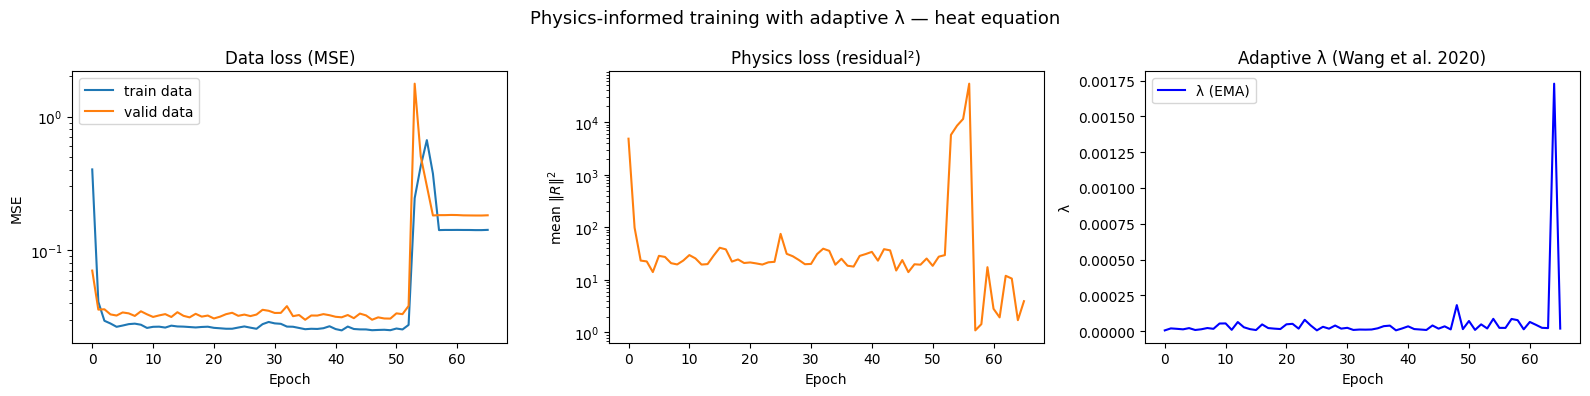

Data-only model  — test rel L2: 5.5830%
PI model (final λ=1.0000) — test rel L2: 4.8002%


In [67]:
# ── 15. Loss curves & λ evolution ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Data loss
axes[0].semilogy(hist_pi['train_data'], label='train data')
axes[0].semilogy(hist_pi['valid_data'], label='valid data')
axes[0].set_title('Data loss (MSE)')
axes[0].legend(); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')

# Physics loss
axes[1].semilogy(hist_pi['train_phys'], color='tab:orange')
axes[1].set_title('Physics loss (residual²)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('mean $\\|R\\|^2$')

# λ evolution (adaptive weighting)
if 'lambda' in hist_pi:
    axes[2].plot(hist_pi['lambda'], 'b-', lw=1.5, label='λ (EMA)')
    # axes[2].plot(hist_pi['lambda_hat'], 'r--', lw=0.8, alpha=0.5, label='λ̂ (raw)')
    axes[2].set_title('Adaptive λ (Wang et al. 2020)')
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('λ')
    axes[2].legend()
    # axes[2].axhline(1.0, color='k', ls=':', lw=0.7, alpha=0.5)

plt.suptitle(f'Physics-informed training with adaptive λ — heat equation', fontsize=13)
plt.tight_layout(); plt.show()

# ── Test error comparison ──
preds_pi_s = jax.vmap(model_pi)(test_cde['ts'], test_cde['coeffs'])
preds_pi_test   = scaler.inverse_transform(np.array(preds_pi_s)) @ V
rmsre_pi_test  = rmsre(preds_pi_test, Y_test)

print(f"Data-only model  — test rel L2: {rmsre_test*100:.4f}%")
print(f"PI model (final λ={lam:.4f}) — test rel L2: {rmsre_pi_test*100:.4f}%")

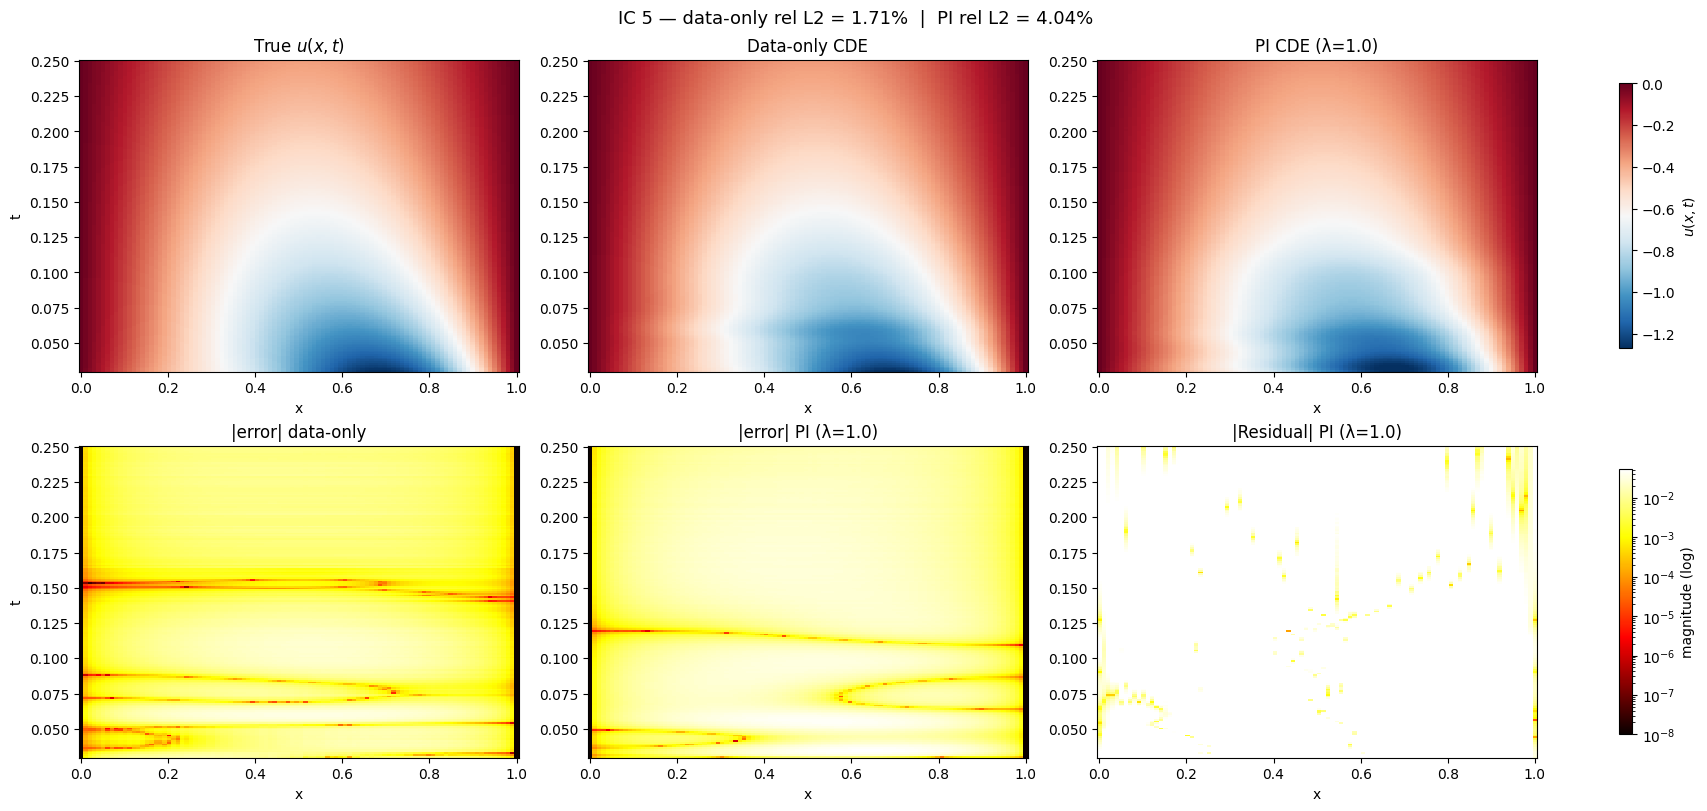

In [68]:
# ── 16. Sequential prediction — show one IC as space-time contour ────
which = np.random.choice(N_ics, 1, replace=False)[0]
U_ic = U_all[which]
S_ic = U_ic[:, sensor_idx_cde]
tc = np.linspace(0, 1, Nt_cde)[:, None]
S_ic_t = np.hstack([S_ic, tc])
X_ic = np.stack([S_ic_t[j : j + lag] for j in range(Nt_cde - lag + 1)])
Y_ic = U_ic[lag - 1:]

cde_ic, _ = prepare_data_CDE(X_ic, Y_ic @ V.T)  # dummy Y for coeffs

# Data-only predictions
preds_data_s = jax.vmap(model_cde)(cde_ic['ts'], cde_ic['coeffs'])
preds_data   = scaler.inverse_transform(np.array(preds_data_s)) @ V

# PI predictions
preds_pi_ic_s = jax.vmap(model_pi)(cde_ic['ts'], cde_ic['coeffs'])
preds_pi_ic   = scaler.inverse_transform(np.array(preds_pi_ic_s)) @ V

U_true_ic = U_ic[lag - 1:]
t_seq_ic  = t_cde[lag - 1:]

vmin, vmax = U_true_ic.min(), U_true_ic.max()
kw = dict(shading='auto', cmap='RdBu_r', vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(2, 3, figsize=(17, 8), layout='constrained')

# Row 0: fields
im_f0 = axes[0, 0].pcolormesh(x_cde, t_seq_ic, U_true_ic, **kw)
axes[0, 0].set_title('True $u(x,t)$'); axes[0, 0].set_ylabel('t')

axes[0, 1].pcolormesh(x_cde, t_seq_ic, preds_data, **kw)
axes[0, 1].set_title('Data-only CDE')

axes[0, 2].pcolormesh(x_cde, t_seq_ic, preds_pi_ic, **kw)
axes[0, 2].set_title(f'PI CDE (λ={lam})')

fig.colorbar(im_f0, ax=axes[0, :].tolist(), shrink=0.85, label='$u(x,t)$')

# Row 1: errors
from matplotlib.colors import LogNorm
err_data_ic = np.abs(U_true_ic - preds_data)
err_pi_ic   = np.abs(U_true_ic - preds_pi_ic)

all_pos = np.concatenate([err_data_ic.ravel(), err_pi_ic.ravel()])
all_pos = all_pos[all_pos > 0]
emin = max(all_pos.min(), 1e-8)
emax = all_pos.max()
err_norm = LogNorm(vmin=emin, vmax=emax)

im_d = axes[1, 0].pcolormesh(x_cde, t_seq_ic, np.clip(err_data_ic, emin, None),
                              shading='auto', cmap='hot', norm=err_norm)
axes[1, 0].set_title('|error| data-only'); axes[1, 0].set_ylabel('t')

im_p = axes[1, 1].pcolormesh(x_cde, t_seq_ic, np.clip(err_pi_ic, emin, None),
                              shading='auto', cmap='hot', norm=err_norm)
axes[1, 1].set_title(f'|error| PI (λ={lam})')

# Physics residual for PI model

u_pi_ic, dudt_pi_ic, d2udx2_pi_ic, res_pi_ic= jax.vmap(
    pred_and_derivs_single_window,
    in_axes=(None, 0, 0, None),
)(model_pi, cde_ic['ts'], cde_ic['coeffs'], alpha)
res_pi_ic = np.array(res_pi_ic)

im_r = axes[1, 2].pcolormesh(x_cde, t_seq_ic, np.clip(np.abs(res_pi_ic), emin, None),
                              shading='auto', cmap='hot', norm=err_norm)
axes[1, 2].set_title(f'|Residual| PI (λ={lam})')

fig.colorbar(im_d, ax=axes[1, :].tolist(), shrink=0.85, label='magnitude (log)')

for ax in axes.flat:
    ax.set_xlabel('x')

rel_data_ic = rmsre(U_true_ic, preds_data) # np.linalg.norm(U_true_ic - preds_data) / np.linalg.norm(U_true_ic)
rel_pi_ic   = rmsre(U_true_ic, preds_pi_ic)# np.linalg.norm(U_true_ic - preds_pi_ic) / np.linalg.norm(U_true_ic)

fig.suptitle(f'IC {which} — data-only rel L2 = {rel_data_ic*100:.2f}%  |  PI rel L2 = {rel_pi_ic*100:.2f}%',
             fontsize=13)
plt.show()

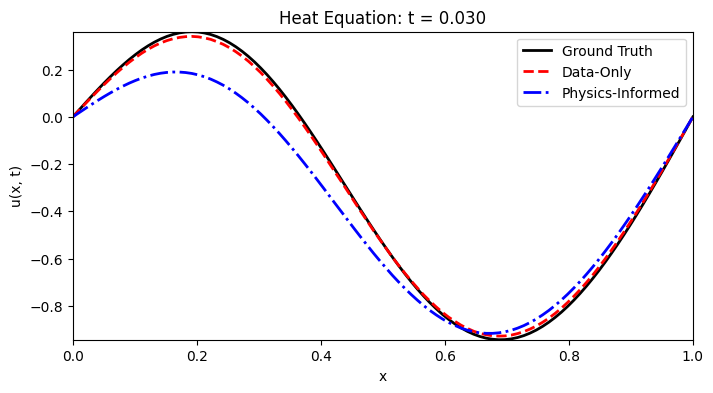

In [69]:
# ── 20. Animation: Data-driven vs PI vs Ground Truth ─────────────────────
import matplotlib.animation as animation

# Select a test IC (trajectory)
which_anim = np.random.choice(N_ics, 1, replace=False)[0]
U_ic_anim = U_all[which_anim]
S_ic_anim = U_ic_anim[:, sensor_idx_cde]
tc_anim = np.linspace(0, 1, Nt_cde)[:, None]
S_ic_t_anim = np.hstack([S_ic_anim, tc_anim])
X_ic_anim = np.stack([S_ic_t_anim[j : j + lag] for j in range(Nt_cde - lag + 1)])
Y_ic_anim = U_ic_anim[lag - 1:]

cde_ic_anim, _ = prepare_data_CDE(X_ic_anim, Y_ic_anim @ V.T)  # dummy Y for coeffs

# Data-only predictions
preds_data_s_anim = jax.vmap(model_cde)(cde_ic_anim['ts'], cde_ic_anim['coeffs'])
preds_data_anim   = scaler.inverse_transform(np.array(preds_data_s_anim)) @ V

# PI predictions
preds_pi_ic_s_anim = jax.vmap(model_pi)(cde_ic_anim['ts'], cde_ic_anim['coeffs'])
preds_pi_ic_anim   = scaler.inverse_transform(np.array(preds_pi_ic_s_anim)) @ V

U_true_anim = Y_ic_anim

t_seq_anim  = t_cde[lag - 1:]

fig, ax = plt.subplots(figsize=(8, 4))
line_true, = ax.plot([], [], 'k-', lw=2, label='Ground Truth')
line_data, = ax.plot([], [], 'r--', lw=2, label='Data-Only')
line_pi,   = ax.plot([], [], 'b-.', lw=2, label='Physics-Informed')
ax.set_xlim(x_cde[0], x_cde[-1])
ax.set_ylim(np.min(U_true_anim), np.max(U_true_anim))
ax.set_xlabel('x')
ax.set_ylabel('u(x, t)')
ax.set_title('Heat Equation: Model Comparison Animation')
ax.legend(loc='upper right')

# Animation update function
def update(frame):
    line_true.set_data(x_cde, U_true_anim[frame])
    line_data.set_data(x_cde, preds_data_anim[frame])
    line_pi.set_data(x_cde, preds_pi_ic_anim[frame])
    ax.set_title(f'Heat Equation: t = {t_seq_anim[frame]:.3f}')
    return line_true, line_data, line_pi

ani = animation.FuncAnimation(fig, update, frames=len(t_seq_anim), interval=60, blit=True)
plt.show()

# To save the animation as a .mp4 file, uncomment below (requires ffmpeg):
ani.save('heat_eqn_comparison.mp4', writer='ffmpeg', fps=20)


In [71]:
# ── 19. Summary Table: MSE, MRE, Physics Loss ────────────────────────
import pandas as pd

# ── Compute metrics on TEST set ──


# ── MSE (Mean Squared Error) ──
mse_data = np.mean(np.sum((preds_data_test - Y_test)**2, axis = -1))
mse_pi   = np.mean(np.sum((preds_pi_test - Y_test)**2, axis = -1))

# ── MRE (Mean Relative Error) ──
mre_data = rmsre(preds_data_test, Y_test)
mre_pi   = rmsre(preds_pi_test, Y_test)

# ── Physics loss (heat equation residual) on test set ──
def compute_physics_loss_batch(model, data, alpha):
    """Compute mean physics residual ‖R‖² over a dataset."""
    _, _, _, residuals = jax.vmap(pred_and_derivs_single_window, in_axes=(None, 0,0, None))(model, data['ts'], data['coeffs'], alpha)
    return float(jnp.mean(jnp.sum(residuals**2, axis=-1)))

phys_loss_data = compute_physics_loss_batch(model_cde, test_cde, alpha)
phys_loss_pi   = compute_physics_loss_batch(model_pi, test_cde, alpha)

# ── Combined loss: L_data + λ·L_physics ──
combined_data = mse_data + lam * phys_loss_data
combined_pi   = mse_pi   + lam * phys_loss_pi

# ── Build table ──
metrics_df = pd.DataFrame({
    'Metric': ['MSE', 'MRE (%)', f'Physics Loss (‖R‖²)', f'Combined (λ={lam})'],
    'Data-Only': [f'{mse_data:.4e}', f'{mre_data*100:.2f}', f'{phys_loss_data:.4e}', f'{combined_data:.4e}'],
    'Physics-Informed': [f'{mse_pi:.4e}', f'{mre_pi*100:.2f}', f'{phys_loss_pi:.4e}', f'{combined_pi:.4e}'],
})
metrics_df = metrics_df.set_index('Metric')

print("="*60)
print("         Neural CDE Performance Summary (Test Set)")
print("="*60)
display(metrics_df)
print()


         Neural CDE Performance Summary (Test Set)


,Data-Only,Physics-Informed
Metric,,
MSE,1.4466e-02,4.3648e-02
MRE (%),5.58,4.80
Physics Loss (‖R‖²),2.1316e+03,9.9732e+01
Combined (λ=1.0),2.1316e+03,9.9776e+01
